# Tujuan, Hipotesis, dan Data

1. Tujuan:
* Mencari apakah ada perbedaan rata-rata dari peserta sebelum dan sesudah mengikuti pengabdian masyarakat berupa webinar. Diukur dengan nilai pretest dan posttest pada peserta yang sama.

2. Hipotesis:
* H0 = Tidak ada perbedaan rata-rata antara pretest dan posttest
* H1 = Ada perbedaan rata-rata antara pretest dan posttest

3. Data:
* Data didapatkan dari data primer yang dikumpulkan melalui 2 kuesioner Google Form saat pendaftaran sekaligus pretest, dan saat presensi sekaligus posttest.

# Data Preprocessing

Data sudah bersih. Aslinya banyak preprocessing yang dilakukan seperti:
1. Cek ulang data nomor telepon dan nama agar nama yang sama harus memiliki nomor telepon yang sama
2. Join tabel Pretest dan Posttest berdasarkan Nomor Telepon
3. Banyak yang mengisi pretest tapi sedikit yang mengisi posttest. Jadi diinformasikan dan dihimbau lagi untuk tidak lupa mengisi
4. Ada kesalahan input peserta untuk pretest-posttest dengan nilai rata kiri (semua 1). Jadi diminta untuk mengisi ulang.
5. Drop kolom yang tidak perlu
6. Mengubah kolom Q1, Q2, ..., Q12 menjadi nilai peserta. Dengan rumus `Nilai yang didapati / Nilai Maksimal * 100`. Setiap pertanyaan (Q) adalah skala Likert.
7. Drop informasi pribadi

# Import dan Load

In [23]:
import pandas as pd
import numpy as np
import matplotlib as mpl
from matplotlib import rcParams
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, ttest_rel, wilcoxon

In [24]:
rcParams['figure.figsize'] = 15, 8
mpl.style.use(['ggplot'])

In [12]:
df_test = pd.read_excel('Pretest-Posttest.xlsx')
df_test

,Pretest,Posttest
0,86.666667,87.777778
1,90.000000,100.000000
2,63.333333,76.666667
3,66.666667,80.000000
4,80.000000,91.111111
5,80.000000,88.888889
6,48.333333,45.555556
7,76.666667,90.000000
8,68.333333,68.888889
9,51.666667,80.000000


# Eksplorasi dan Visualisasi

In [13]:
print('Nilai rata-rata Pretest = ', np.round(df_test['Pretest'].mean(), decimals=2))
print('Nilai rata-rata Posttest = ', np.round(df_test['Posttest'].mean(), decimals=2))
print('Selisih = ', np.round((df_test['Posttest'].mean() - df_test['Pretest'].mean()), decimals=2))

Nilai rata-rata Pretest =  70.83
Nilai rata-rata Posttest =  80.95
Selisih =  10.12


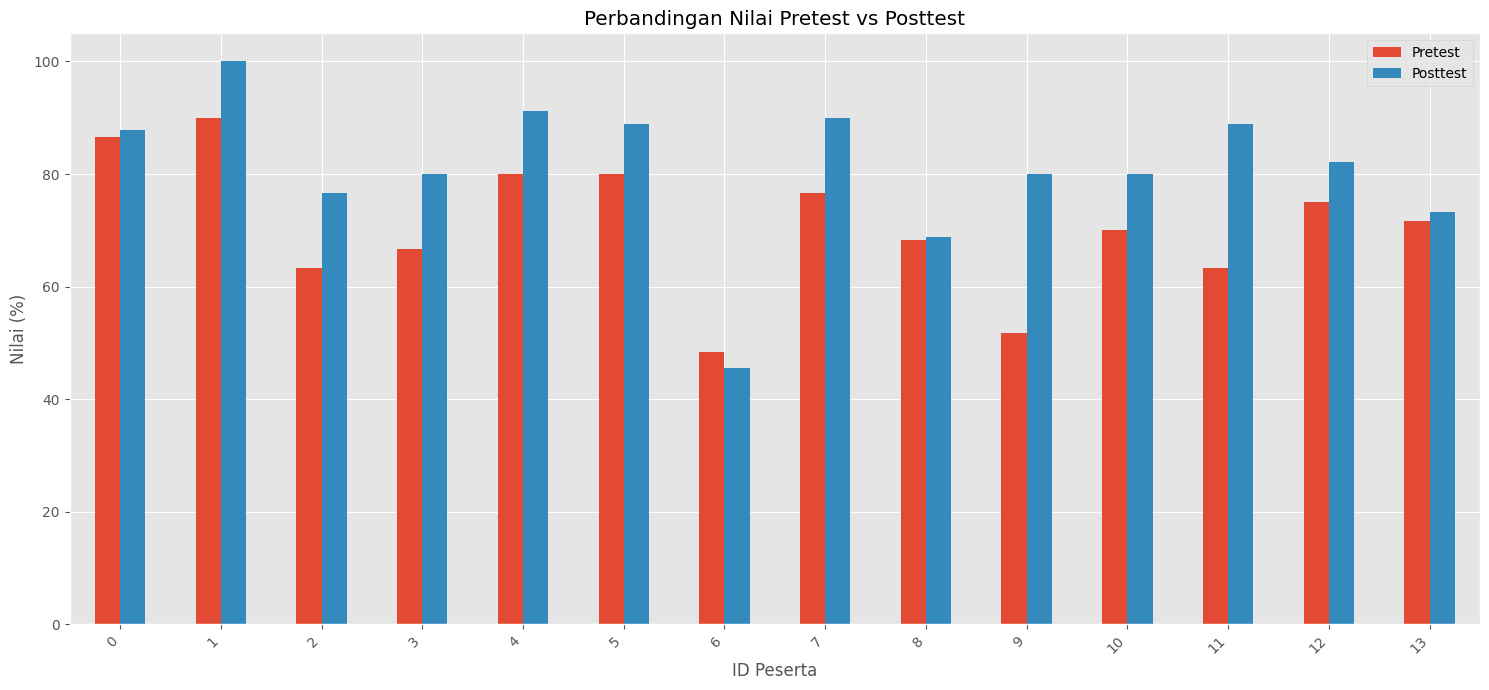

In [14]:
df_test.plot(kind='bar', figsize=(15, 7))
plt.title('Perbandingan Nilai Pretest vs Posttest')
plt.ylabel('Nilai (%)')
plt.xlabel('ID Peserta')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



In [27]:
diff = df_test['Posttest'] - df_test['Pretest']
diff

,0
0,1.111111
1,10.000000
2,13.333333
3,13.333333
4,11.111111
5,8.888889
6,-2.777778
7,13.333333
8,0.555556
9,28.333333


# Uji Normalitas

Untuk data n < 50, pakai Shapiro-Wilk.

Untuk data n >= 50, pakai Kolmogorov-Smirnov

In [28]:
stat_sw, p_sw = shapiro(diff)
print(f"Nilai Statistik Shapiro-Wilk: {stat_sw:.4f}")
print(f"Shapiro-Wilk (Normalitas Selisih) p-value: {p_sw:.4f}")

Nilai Statistik Shapiro-Wilk: 0.9195
Shapiro-Wilk (Normalitas Selisih) p-value: 0.2164


* Nilai p_value Shapiro adalah 0.21 atau di atas 0.05, sehingga data berdistribusi normal dan bisa menggunakan Paired T Test atau `ttest_rel`
* Jika data tidak normal, maka akan pakai Wilcoxon Signed-Rank Test atau `wilcoxon`

# Uji Hipotesis

In [29]:
if p_sw > 0.05:
    # Jika normal, gunakan T-test
    t_stat, p_ttest = ttest_rel(df_test['Posttest'], df_test['Pretest'])
    print(f"Nilai statistik T: {t_stat:.4f}")
    print(f"Nilai p-value: {p_ttest:.4f}")
else:
    # Jika TIDAK normal, gunakan alternatif Non-Parametrik
    print("Data tidak normal, menggunakan Wilcoxon Signed-Rank Test...")
    stat_w, p_wilcoxon = wilcoxon(df_test['Posttest'], df_test['Pretest'])
    print(f"Nilai statistik Wilcoxon: {stat_w:.4f}")
    print(f"Nilai p-value: {p_wilcoxon:.4f}")

Nilai statistik T: 4.2695
Nilai p-value: 0.0009


# Jawaban

* Dengan menggunakan selisih rata-rata biasa, terdapat peningkatan nilai 10.12 dari Pretest 70.83 ke Posttest 80.95
* Nilai P_Value adalah 0.0009 atau lebih kecil dari 0.05. Hal ini berarti hasil signifikan sehingga kita menolak H0 yaitu tidak ada perbedaan rata-rata menjadi menerima H1 yaitu ada perbedaan rata-rata